In [ ]:
### Notebook here compares the proportion of c-mod and non-c-mod target annotations that are kinases, including:
### > Running filtering of c-mods and non-c-mods
### > Analysing the proportion of c-mods and non-c-mods that are annotated as kinase inhibitors (Fig 5a)

In [1]:
import ast
import math
import pandas as pd
import numpy as np
import re
from rdkit import Chem, rdBase
import matplotlib.pyplot as plt
import seaborn as sns
import dataframe_image as dfi
from rdkit.Chem import Descriptors, rdMolDescriptors, MACCSkeys
from rdkit.Chem import FilterCatalog
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Draw import IPythonConsole
from umap import UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.utils import resample
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import StratifiedKFold
from scipy.stats import ks_2samp, mannwhitneyu
from scipy.stats import chi2_contingency, fisher_exact

In [2]:
rdBase.DisableLog("rdApp.*")

In [3]:
sns.set_style("whitegrid")

In [4]:
### Load and filter compounds

In [5]:
#Load dataset of c-mods from d.paint 20 screen
cmods_df = pd.read_csv("./data/dpaint20_cmods.csv")
cmods_df["chemformer"] = cmods_df["chemformer"].apply(ast.literal_eval)
cmods_df["Set"] = "C-mod"

In [6]:
#Load dataset of "FDA library" compounds, a subset of which was used for the d.paint 20 screen
non_cmods_df = pd.read_csv("./data/updated_fda.csv")
non_cmods_df["chemformer"] = non_cmods_df["chemformer"].apply(ast.literal_eval)
non_cmods_df["Set"] = "Non c-mod"

In [7]:
#Remove d.paint c-mods from full FDA library compound list
non_cmods_df = non_cmods_df[
    ~non_cmods_df["Molecule Name"].isin(cmods_df["compound_id"].tolist())
].copy()

In [8]:
#Load CD-CODE c-mods dataset
cd_code_cmods_df = pd.read_csv("./data/cdcode_cmods.csv")

In [9]:
#Remove CD-Code c-mods from FDA library compound list
non_cmods_df = non_cmods_df[
    ~non_cmods_df["canon_smiles"].isin(cd_code_cmods_df["canon_smiles"].tolist())
].copy()

In [10]:
#Load list of all compounds used in d.paint 20 screen
dpaint20_cmpds_df = pd.read_excel(
    "./data/dpaint20_cmpds_and_cmods.xlsx",
    sheet_name="cmpds",
)

In [11]:
#Limit non-c-mods dataset ("FDA library compounds") only to compounds included in the d.paint 20 screen
non_cmods_df = non_cmods_df[non_cmods_df["Molecule Name"].isin(dpaint20_cmpds_df["compound"])].copy()

In [12]:
#Check no overlap between c-mod and non-c-mod dfs
inter = len(
    set(non_cmods_df["Molecule Name"].tolist()).intersection(
        set(cmods_df["compound_id"].tolist())
    )
)

assert inter == 0, "Intersection between FDA and FDA c-mod"

In [13]:
#Function to calculate chemical descriptors

def calc_mol_desc(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    def safe_div(num, denom):
        return float(num) / float(denom) if denom else 0.0
    
    num_heavy_atoms = Descriptors.HeavyAtomCount(mol)
    num_aromatic_atoms = sum(atom.GetIsAromatic() for atom in mol.GetAtoms())
    num_ring_atoms = sum(atom.IsInRing() for atom in mol.GetAtoms())
    valence_e = Descriptors.NumValenceElectrons(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    num_rotatable_bonds = Descriptors.NumRotatableBonds(mol)
    
    return {
        "QED": Descriptors.qed(mol),
        "LogP": Descriptors.MolLogP(mol),
        "MW": Descriptors.ExactMolWt(mol),
        "# of valence electrons": Descriptors.NumValenceElectrons(mol),
        "# of rings": Descriptors.RingCount(mol),
#        "# of heavy atoms": Descriptors.HeavyAtomCount(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "# of rotatable bonds": num_rotatable_bonds,
        "TPSA": Descriptors.TPSA(mol),
        "# of aromatic rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "ratio rotatable bonds to atoms": safe_div(num_rotatable_bonds,num_heavy_atoms),
        "fraction atoms in aromatic rings": safe_div(num_aromatic_atoms,num_heavy_atoms), 
        "fraction atoms in rings": safe_div(num_ring_atoms,num_heavy_atoms),
        "ratio valence electrons to atoms": safe_div(valence_e,num_heavy_atoms),
        "fraction HBD": safe_div(hbd,num_heavy_atoms),
        "fraction HBA": safe_div(hba,num_heavy_atoms),
    }

In [14]:
#Calculate chemical descriptors for c-mods
mol_desc = cmods_df["canon_smiles"].apply(calc_mol_desc)
mol_desc = mol_desc.apply(pd.Series)
desc_cols = mol_desc.columns
cmods_df = cmods_df.join(mol_desc)

In [15]:
#Calculate chemical descriptors for non-c-mods
mol_desc = non_cmods_df["canon_smiles"].apply(calc_mol_desc)
mol_desc = mol_desc.apply(pd.Series)
non_cmods_df = non_cmods_df.join(mol_desc)

In [16]:
#Function to build PAINS catalog for filtering
def build_pains_catalog():
    pains_params = FilterCatalog.FilterCatalogParams()
    pains_sets = [
        FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_A,
        FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_B,
#        FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_C, << Only use High (A) and Medium (B) filters for now
    ]
    for p in pains_sets:
        pains_params.AddCatalog(p)
    return FilterCatalog.FilterCatalog(pains_params)

pains_catalog = build_pains_catalog()

In [17]:
#Function to remove any null smiles
def smiles_to_mol(smiles):
    if pd.isna(smiles):
        return None
    return Chem.MolFromSmiles(smiles)

In [18]:
#Function to run PAINS filtering using catalog generated
def is_pains(mol):
    return pains_catalog.HasMatch(mol)

In [19]:
#Apply to c-mods
cmods_df["rdkit_mol"] = cmods_df["SMILES"].apply(smiles_to_mol)

cmods_df["is_pains"] = cmods_df["rdkit_mol"].apply(is_pains)

cmods_filtered_df = cmods_df[~cmods_df["is_pains"]].copy()

In [20]:
#Apply to non-c-mods
non_cmods_df["rdkit_mol"] = non_cmods_df["SMILES"].apply(smiles_to_mol)

non_cmods_df["is_pains"] = non_cmods_df["rdkit_mol"].apply(is_pains)

non_cmods_filtered_df = non_cmods_df[~non_cmods_df["is_pains"]].copy()

In [21]:
#Remove any c-mods >1000Da
cmods_filtered_df = cmods_filtered_df[cmods_filtered_df["MW"] < 1000]

In [22]:
#Remove any non-c-mods >1000Da
non_cmods_filtered_df = non_cmods_filtered_df[non_cmods_filtered_df["MW"] < 1000]

In [23]:
#Check number of compounds in each set, before and after filtering
pd.DataFrame(
    {
        "C-mod": [len(cmods_df)],
        "Filtered c-mod": [len(cmods_filtered_df)],
        "Non c-mod": [len(non_cmods_df)],
        "Filtered non-c-mod": [len(non_cmods_filtered_df)],
    },
    index=["Number of compounds"],
).style.set_table_styles(
    [
        {"selector": "td", "props": [("border", "1px solid black")]},
        {"selector": "th", "props": [("border", "1px solid black")]},
        {"selector": "th.col_heading", "props": [("background-color", "lightgray")]},
        {"selector": "th.row_heading", "props": [("background-color", "lightgray")]},
        {"selector": "caption", "props": [("font-weight", "bold")]},
    ],
).format(
    "{:,}"
)

,C-mod,Filtered c-mod,Non c-mod,Filtered non-c-mod
Number of compounds,587,512,"3,788","3,447"


In [25]:
#Check overlap between c-mods and non-c-mods again
if len(
    set(cmods_filtered_df["SMILES"].tolist()).intersection(
        set(non_cmods_filtered_df["SMILES"].tolist())
    )
):
    print("There is overlap between c-mod and non-c-mod datasets")

In [26]:
### Kinase target proportion analysis

In [27]:
#Load kinase target annotations
df_target = pd.read_excel(
    "./data/updated_fda_kinase_target_annotation.xlsx",
    sheet_name="all",
)

In [28]:
#Merge target annotations for c-mods
cmods_filtered_df = cmods_filtered_df.merge(
    df_target[["compound_id", "target", "target_kinase"]],
    on="compound_id",
    how="inner",
)

In [29]:
#Rename for consistency
non_cmods_filtered_df = non_cmods_filtered_df.rename(columns={"Molecule Name": "compound_id"})

In [30]:
#Merge target annotations for non-c-mods
non_cmods_filtered_df = non_cmods_filtered_df.merge(
    df_target[["compound_id", "target", "target_kinase"]],
    on="compound_id",
    how="inner",
)

In [31]:
# Calculate kinase proportions for c-mods and non-c-mods
def kinase_props(df, name):
    s = df["target_kinase"].astype(int)
    return pd.Series({
        "n": len(s),
        "non_kinase_count (0)": int((s == 0).sum()),
        "non_kinase_prop (0)": float((s == 0).mean()),
        "kinase_count (1)": int((s == 1).sum()),
        "kinase_prop (1)": float((s == 1).mean()),
    }, name=name)

summary = pd.DataFrame([
    kinase_props(cmods_filtered_df, "cmods_filtered_df"),
    kinase_props(non_cmods_filtered_df, "non_cmods_filtered_df"),
])

summary


,n,non_kinase_count (0),non_kinase_prop (0),kinase_count (1),kinase_prop (1)
cmods_filtered_df,512.0,302.0,0.589844,210.0,0.410156
non_cmods_filtered_df,3416.0,3002.0,0.878806,414.0,0.121194


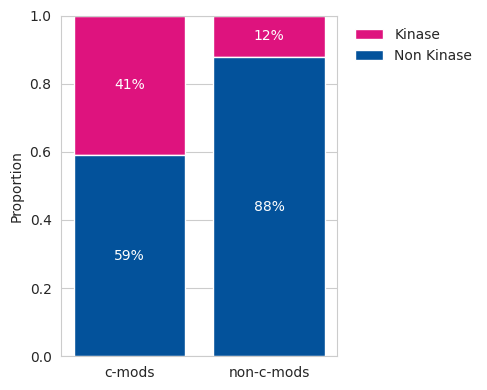

In [32]:
#Produce a plot
plot_df = summary[["non_kinase_prop (0)", "kinase_prop (1)"]].copy()
plot_df.columns = ["Non-kinase", "Kinase"]

plot_df.index = ["c-mods", "non-c-mods"]

x = np.arange(len(plot_df))
nonk = plot_df["Non-kinase"].to_numpy()
k = plot_df["Kinase"].to_numpy()

fig, ax = plt.subplots(figsize=(5, 4))

# --- Stacked bars with custom colors ---
ax.bar(
    x, k,
    bottom=nonk,
    label="Kinase",
    color="#DE137E"
)

ax.bar(
    x, nonk,
    label="Non Kinase",
    color="#03529B"
)

# Add % labels inside segments
for i, (a, b) in enumerate(zip(nonk, k)):
    if a > 0:
        ax.text(i, a/2, f"{a:.0%}", ha="center", va="center", color="white")
    if b > 0:
        ax.text(i, a + b/2, f"{b:.0%}", ha="center", va="center", color="white")

ax.set_xticks(x, plot_df.index)
ax.set_ylim(0, 1)
ax.set_ylabel("Proportion")

# --- Move legend outside ---
ax.legend(
    frameon=False,
    bbox_to_anchor=(1.02, 1),   # move right of plot
    loc="upper left"
)

plt.tight_layout()
#plt.savefig("./figures/kinase_enrichment.png")
plt.show()

In [33]:
#Calculate statistical significance using chi-squared

table = np.array([
    [
        int((cmods_filtered_df["target_kinase"].astype(int) == 1).sum()),
        int((cmods_filtered_df["target_kinase"].astype(int) == 0).sum()),
    ],
    [
        int((non_cmods_filtered_df["target_kinase"].astype(int) == 1).sum()),
        int((non_cmods_filtered_df["target_kinase"].astype(int) == 0).sum()),
    ],
])

chi2, p_chi2, dof, expected = chi2_contingency(table, correction=True)

print("Contingency table [[c-mods kinase, c-mods non-kinase],[non-c-mods kinase, non-c-mods non-kinase]]:\n", table)
print("\nChi-squared test (with Yates correction for 2x2):")
print(f"  chi2={chi2:.4g}, dof={dof}, p={p_chi2:.4g}")
print("  expected counts under null:\n", expected)


Contingency table [[c-mods kinase, c-mods non-kinase],[non-c-mods kinase, non-c-mods non-kinase]]:
 [[ 210  302]
 [ 414 3002]]

Chi-squared test (with Yates correction for 2x2):
  chi2=276.1, dof=1, p=5.371e-62
  expected counts under null:
 [[  81.33604888  430.66395112]
 [ 542.66395112 2873.33604888]]
